# Assignment 2 — Language Identification with FastText Wiki Vectors

Builds on the 23-language dataset from Assignment 1 (`data/train.jsonl`, `data/val.jsonl`, `data/test.jsonl`,
fields `text` and `label`). Trains and compares:

1. Logistic Regression on averaged FastText word vectors
2. MLP with 0 / 1 / 2 hidden layers
3. LSTM
4. GRU
5. FastText supervised classifier

Evaluation metric: **macro-F1, implemented from scratch (no `sklearn.metrics`)**.

**Run this on Kaggle** (Settings → Internet: On, Accelerator: GPU T4). It streams ~23 pretrained FastText
Wikipedia vector files, which needs an internet-enabled, decently fast environment — see the note at the
bottom of this notebook for why Kaggle beats local VS Code here.


In [1]:
# If fasttext fails to build from source, try: pip install fasttext-wheel
!pip install -q fasttext torch pandas requests tqdm


In [2]:
import os, re, json, io, gzip, math, random
from collections import defaultdict

import numpy as np
import requests
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## 1. Load the Assignment-1 dataset

Point `DATA_DIR` at wherever you kept `train.jsonl` / `val.jsonl` / `test.jsonl` from Assignment 1
(e.g. a Kaggle Dataset you upload and attach, at `/kaggle/input/<your-dataset>/data`).

If the files aren't found, the next cell regenerates them from scratch using the exact same
IndicCorpV2-based pipeline from Assignment 1, so this notebook is fully self-contained.


In [3]:
DATA_DIR = "data"  # <-- change this if you uploaded Assignment 1's output as a Kaggle Dataset

def _files_present():
    return all(os.path.exists(os.path.join(DATA_DIR, f"{s}.jsonl")) for s in ("train", "val", "test"))

print("Assignment-1 data found:" , _files_present())


Assignment-1 data found: False


In [4]:
# --- Fallback: regenerate the Assignment-1 dataset if it isn't available ---
# (identical logic to Assignment 1 — only runs if train/val/test.jsonl are missing)
if not _files_present():
    print("Regenerating dataset from IndicCorpV2 (this can take a while)...")
    from pathlib import Path
    from datasets import load_dataset

    _SENT_END_CHARS = ".!?।॥۔؟"
    _MULTI_PUNCT_RE = re.compile(rf"([{_SENT_END_CHARS}])\1+")
    _SPLIT_RE = re.compile(rf"(?<=[{_SENT_END_CHARS}])\s+")
    _WS_RE = re.compile(r"\s+")

    def sentence_tokenize(paragraph):
        if not paragraph:
            return []
        text = paragraph.replace("\n", " ").replace("\t", " ").strip()
        text = _WS_RE.sub(" ", text)
        text = _MULTI_PUNCT_RE.sub(r"\1", text)
        if not text:
            return []
        pieces = _SPLIT_RE.split(text)
        return [p.strip() for p in pieces if p.strip()]

    REPO_ID = "ai4bharat/IndicCorpV2"
    LANGUAGES = [
        "asm_Beng", "ben_Beng", "brx_Deva", "doi_Deva", "gom_Deva", "guj_Gujr",
        "hin_Deva", "kan_Knda", "kas_Arab", "mai_Deva", "mal_Mlym", "mar_Deva",
        "mni_Mtei", "npi_Deva", "ory_Orya", "pan_Guru", "san_Deva", "snd_Deva",
        "tam_Taml", "tel_Telu", "urd_Arab", "khasi", "santhali",
    ]
    SENTS_PER_LANG = 1000
    MIN_CHARS = 15
    MIN_WORDS = 3
    MAX_PARAGRAPHS_TO_SCAN = 200_000
    OUT_DIR = Path(DATA_DIR)
    OUT_DIR.mkdir(exist_ok=True, parents=True)

    def build_language_dataset():
        all_rows = []
        for lang in LANGUAGES:
            out_path = OUT_DIR / f"_raw_{lang}.jsonl"
            if out_path.exists():
                with open(out_path, encoding="utf-8") as f:
                    for line in f:
                        row = json.loads(line)
                        all_rows.append((row["text"], row["label"]))
                continue
            print(f"=== Collecting sentences for '{lang}' ===", flush=True)
            collected = set()
            ds = load_dataset(REPO_ID, split=lang, streaming=True)
            scanned = 0
            for example in ds:
                scanned += 1
                para = example.get("text", "") or example.get("sentence", "")
                if not para:
                    continue
                for sent in sentence_tokenize(para):
                    if len(sent) < MIN_CHARS or len(sent.split()) < MIN_WORDS:
                        continue
                    if sent in collected:
                        continue
                    collected.add(sent)
                    if len(collected) >= SENTS_PER_LANG:
                        break
                if len(collected) >= SENTS_PER_LANG or scanned >= MAX_PARAGRAPHS_TO_SCAN:
                    break
            with open(out_path, "w", encoding="utf-8") as f:
                for s in collected:
                    f.write(json.dumps({"text": s, "label": lang}, ensure_ascii=False) + "\n")
            for s in collected:
                all_rows.append((s, lang))
        return all_rows

    def stratified_split(rows, train_ratio=0.8, val_ratio=0.1):
        by_label = {}
        for text, label in rows:
            by_label.setdefault(label, []).append(text)
        train, val, test = [], [], []
        for label, texts in by_label.items():
            texts = texts[:]
            random.shuffle(texts)
            n = len(texts)
            n_train = int(round(n * train_ratio))
            n_val = int(round(n * val_ratio))
            train += [(t, label) for t in texts[:n_train]]
            val += [(t, label) for t in texts[n_train:n_train + n_val]]
            test += [(t, label) for t in texts[n_train + n_val:]]
        random.shuffle(train); random.shuffle(val); random.shuffle(test)
        return train, val, test

    def save_split(rows, name):
        path = OUT_DIR / f"{name}.jsonl"
        with open(path, "w", encoding="utf-8") as f:
            for text, label in rows:
                f.write(json.dumps({"text": text, "label": label}, ensure_ascii=False) + "\n")
        print(f"Saved {len(rows)} rows -> {path}")

    rows = build_language_dataset()
    train, val, test = stratified_split(rows)
    save_split(train, "train"); save_split(val, "val"); save_split(test, "test")
    print("Done regenerating.")


Regenerating dataset from IndicCorpV2 (this can take a while)...
=== Collecting sentences for 'asm_Beng' ===


README.md: 0.00B [00:00, ?B/s]

=== Collecting sentences for 'ben_Beng' ===
=== Collecting sentences for 'brx_Deva' ===
=== Collecting sentences for 'doi_Deva' ===
=== Collecting sentences for 'gom_Deva' ===
=== Collecting sentences for 'guj_Gujr' ===
=== Collecting sentences for 'hin_Deva' ===
=== Collecting sentences for 'kan_Knda' ===
=== Collecting sentences for 'kas_Arab' ===
=== Collecting sentences for 'mai_Deva' ===
=== Collecting sentences for 'mal_Mlym' ===
=== Collecting sentences for 'mar_Deva' ===
=== Collecting sentences for 'mni_Mtei' ===
=== Collecting sentences for 'npi_Deva' ===
=== Collecting sentences for 'ory_Orya' ===
=== Collecting sentences for 'pan_Guru' ===
=== Collecting sentences for 'san_Deva' ===
=== Collecting sentences for 'snd_Deva' ===
=== Collecting sentences for 'tam_Taml' ===
=== Collecting sentences for 'tel_Telu' ===
=== Collecting sentences for 'urd_Arab' ===
=== Collecting sentences for 'khasi' ===
=== Collecting sentences for 'santhali' ===
Saved 18400 rows -> data/train.json

In [5]:
def load_split(name):
    path = os.path.join(DATA_DIR, f"{name}.jsonl")
    texts, labels = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            texts.append(row["text"])
            labels.append(row["label"])
    return texts, labels

train_texts, train_labels = load_split("train")
val_texts, val_labels = load_split("val")
test_texts, test_labels = load_split("test")

LABELS = sorted(set(train_labels))
label_to_idx = {l: i for i, l in enumerate(LABELS)}
y_train = np.array([label_to_idx[l] for l in train_labels])
y_val = np.array([label_to_idx[l] for l in val_labels])
y_test = np.array([label_to_idx[l] for l in test_labels])

print(f"{len(LABELS)} languages: {LABELS}")
print(f"train={len(train_texts)}  val={len(val_texts)}  test={len(test_texts)}")


23 languages: ['asm_Beng', 'ben_Beng', 'brx_Deva', 'doi_Deva', 'gom_Deva', 'guj_Gujr', 'hin_Deva', 'kan_Knda', 'kas_Arab', 'khasi', 'mai_Deva', 'mal_Mlym', 'mar_Deva', 'mni_Mtei', 'npi_Deva', 'ory_Orya', 'pan_Guru', 'san_Deva', 'santhali', 'snd_Deva', 'tam_Taml', 'tel_Telu', 'urd_Arab']
train=18400  val=2300  test=2300


## 2. Macro-F1 from scratch

No `sklearn.metrics`. Built directly from a per-class confusion count (TP/FP/FN), matching the
definition of macro-averaged F1 (unweighted mean of per-class F1).


In [6]:
def macro_f1_from_scratch(y_true, y_pred, labels):
    idx = {l: i for i, l in enumerate(labels)}
    n = len(labels)
    tp = [0] * n; fp = [0] * n; fn = [0] * n
    for yt, yp in zip(y_true, y_pred):
        ti, pi = idx[yt], idx[yp]
        if ti == pi:
            tp[ti] += 1
        else:
            fp[pi] += 1
            fn[ti] += 1
    per_class = {}
    for i, lab in enumerate(labels):
        prec = tp[i] / (tp[i] + fp[i]) if (tp[i] + fp[i]) > 0 else 0.0
        rec = tp[i] / (tp[i] + fn[i]) if (tp[i] + fn[i]) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        per_class[lab] = f1
    macro_f1 = sum(per_class.values()) / n
    return macro_f1, per_class


## 3. FastText wiki vectors

Pretrained word vectors from https://fasttext.cc/docs/en/pretrained-vectors.html (`wiki.{code}.vec.gz`,
300-d, Wikipedia-trained, one file per language).

Downloading all 23 full files (multi-GB each) is neither necessary nor practical, so we **stream** each
gzip and keep only the vectors for words that actually appear in our dataset for that language — the
files list words by frequency, so this is fast and memory-light.

**Coverage caveat:** FastText's wiki vectors don't cover every one of our 23 languages — some low-resource
ones (e.g. Bodo, Dogri, Khasi, Santali, Manipuri) may not have a pretrained file at all. The loader below
tries the best-guess ISO code for each language and reports which ones it actually found. Any word without
a pretrained vector (OOV, or an entire unavailable language) falls back to a fixed, seeded random vector —
this keeps the pipeline running end-to-end and the comparison honest; we print per-language availability so
you can call this out explicitly in your report.


In [7]:
_WORD_RE = re.compile(r"\S+")

def tokenize(text):
    return _WORD_RE.findall(text.strip().lower())

def build_vocab_by_lang(texts, labels):
    vocab = defaultdict(set)
    for t, l in zip(texts, labels):
        vocab[l].update(tokenize(t))
    return vocab

all_texts = train_texts + val_texts + test_texts
all_labels_flat = train_labels + val_labels + test_labels
vocab_by_lang = build_vocab_by_lang(all_texts, all_labels_flat)
for lab in LABELS:
    print(f"{lab}: {len(vocab_by_lang[lab])} unique tokens")


asm_Beng: 8876 unique tokens
ben_Beng: 6052 unique tokens
brx_Deva: 7282 unique tokens
doi_Deva: 4792 unique tokens
gom_Deva: 6380 unique tokens
guj_Gujr: 6854 unique tokens
hin_Deva: 5171 unique tokens
kan_Knda: 7231 unique tokens
kas_Arab: 5165 unique tokens
khasi: 7436 unique tokens
mai_Deva: 6317 unique tokens
mal_Mlym: 6712 unique tokens
mar_Deva: 6304 unique tokens
mni_Mtei: 6042 unique tokens
npi_Deva: 6682 unique tokens
ory_Orya: 3730 unique tokens
pan_Guru: 6100 unique tokens
san_Deva: 3811 unique tokens
santhali: 9703 unique tokens
snd_Deva: 6481 unique tokens
tam_Taml: 7369 unique tokens
tel_Telu: 5977 unique tokens
urd_Arab: 7642 unique tokens


In [8]:
# Best-effort dataset-label -> FastText wiki ISO code. Some of these may not exist on the server;
# the loader tries each candidate and moves on if it 404s.
FASTTEXT_CANDIDATES = {
    "asm_Beng": ["as"], "ben_Beng": ["bn"], "brx_Deva": ["brx"], "doi_Deva": ["doi"],
    "gom_Deva": ["gom"], "guj_Gujr": ["gu"], "hin_Deva": ["hi"], "kan_Knda": ["kn"],
    "kas_Arab": ["ks"], "mai_Deva": ["mai"], "mal_Mlym": ["ml"], "mar_Deva": ["mr"],
    "mni_Mtei": ["mni"], "npi_Deva": ["ne"], "ory_Orya": ["or"], "pan_Guru": ["pa"],
    "san_Deva": ["sa"], "snd_Deva": ["sd"], "tam_Taml": ["ta"], "tel_Telu": ["te"],
    "urd_Arab": ["ur"], "khasi": ["kha", "khi"], "santhali": ["sat"],
}
FASTTEXT_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.{code}.vec.gz"
EMB_DIM = 300

def try_load_vectors_for_lang(label, needed_words, dim=EMB_DIM, max_lines=2_000_000):
    found = {}
    for code_ in FASTTEXT_CANDIDATES.get(label, []):
        url = FASTTEXT_URL.format(code=code_)
        try:
            resp = requests.get(url, stream=True, timeout=30)
            if resp.status_code != 200:
                continue
            with gzip.GzipFile(fileobj=resp.raw) as gz:
                stream = io.TextIOWrapper(gz, encoding="utf-8", errors="ignore")
                stream.readline()  # header: "<n_words> <dim>"
                for n_lines, line in enumerate(stream):
                    if n_lines > max_lines:
                        break
                    parts = line.rstrip().split(" ")
                    if len(parts) < dim + 1:
                        continue
                    w = parts[0]
                    if w in needed_words and w not in found:
                        try:
                            found[w] = [float(x) for x in parts[1:dim + 1]]
                        except ValueError:
                            continue
                    if len(found) >= len(needed_words):
                        break
            resp.close()
            print(f"  [{label}] code='{code_}': found {len(found)}/{len(needed_words)} words")
            return found, code_
        except Exception as e:
            print(f"  [{label}] code='{code_}' failed: {e}")
            continue
    return found, None

word_vectors = {}
lang_vector_source = {}
for label, words in vocab_by_lang.items():
    found, code_ = try_load_vectors_for_lang(label, words)
    lang_vector_source[label] = code_
    for w, v in found.items():
        word_vectors[w] = np.array(v, dtype=np.float32)

print("\nPretrained vector availability:")
for label in LABELS:
    status = lang_vector_source.get(label) or "NOT AVAILABLE -> fallback random vectors used"
    print(f"  {label}: {status}")



Pretrained vector availability:
  asm_Beng: NOT AVAILABLE -> fallback random vectors used
  ben_Beng: NOT AVAILABLE -> fallback random vectors used
  brx_Deva: NOT AVAILABLE -> fallback random vectors used
  doi_Deva: NOT AVAILABLE -> fallback random vectors used
  gom_Deva: NOT AVAILABLE -> fallback random vectors used
  guj_Gujr: NOT AVAILABLE -> fallback random vectors used
  hin_Deva: NOT AVAILABLE -> fallback random vectors used
  kan_Knda: NOT AVAILABLE -> fallback random vectors used
  kas_Arab: NOT AVAILABLE -> fallback random vectors used
  khasi: NOT AVAILABLE -> fallback random vectors used
  mai_Deva: NOT AVAILABLE -> fallback random vectors used
  mal_Mlym: NOT AVAILABLE -> fallback random vectors used
  mar_Deva: NOT AVAILABLE -> fallback random vectors used
  mni_Mtei: NOT AVAILABLE -> fallback random vectors used
  npi_Deva: NOT AVAILABLE -> fallback random vectors used
  ory_Orya: NOT AVAILABLE -> fallback random vectors used
  pan_Guru: NOT AVAILABLE -> fallback rand

In [9]:
def get_word_vector(word):
    if word in word_vectors:
        return word_vectors[word]
    rng = np.random.RandomState(abs(hash(word)) % (2**32))
    vec = rng.normal(0, 0.1, EMB_DIM).astype(np.float32)
    word_vectors[word] = vec
    return vec


## 4. Method 1 — Logistic Regression on averaged word vectors

Each sentence -> average of its (FastText) word vectors -> single linear layer + softmax
(multinomial logistic regression), trained with a manual loop (no `sklearn.linear_model`).


In [10]:
def sentence_avg_vector(text):
    words = tokenize(text)
    if not words:
        return np.zeros(EMB_DIM, dtype=np.float32)
    return np.mean([get_word_vector(w) for w in words], axis=0)

def build_avg_matrix(texts):
    return np.stack([sentence_avg_vector(t) for t in texts])

X_train_avg = build_avg_matrix(train_texts)
X_val_avg = build_avg_matrix(val_texts)
X_test_avg = build_avg_matrix(test_texts)
print(X_train_avg.shape, X_val_avg.shape, X_test_avg.shape)


(18400, 300) (2300, 300) (2300, 300)


In [11]:
def train_ff_model(model, X_train, y_train, X_val, y_val, epochs=15, lr=1e-3, batch_size=128):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.long)
    dl = DataLoader(torch.utils.data.TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    Xva = torch.tensor(X_val, dtype=torch.float32).to(device)
    yva = torch.tensor(y_val, dtype=torch.long).to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(xb)
        model.eval()
        with torch.no_grad():
            val_acc = (model(Xva).argmax(1) == yva).float().mean().item()
        print(f"  epoch {epoch + 1:>2}/{epochs}  train_loss={total_loss / len(dl.dataset):.4f}  val_acc={val_acc:.4f}")
    return model

def predict_ff(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()


In [12]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.linear = nn.Linear(in_dim, n_classes)
    def forward(self, x):
        return self.linear(x)

print("=== Method 1: Logistic Regression on averaged FastText vectors ===")
lr_model = LogisticRegressionModel(EMB_DIM, len(LABELS))
lr_model = train_ff_model(lr_model, X_train_avg, y_train, X_val_avg, y_val, epochs=15)
lr_pred = [LABELS[i] for i in predict_ff(lr_model, X_test_avg)]
lr_macro_f1, lr_per_class = macro_f1_from_scratch(test_labels, lr_pred, LABELS)
print(f"Logistic Regression macro-F1: {lr_macro_f1:.4f}")


=== Method 1: Logistic Regression on averaged FastText vectors ===
  epoch  1/15  train_loss=3.1024  val_acc=0.3635
  epoch  2/15  train_loss=3.0311  val_acc=0.4261
  epoch  3/15  train_loss=2.9631  val_acc=0.4461
  epoch  4/15  train_loss=2.8980  val_acc=0.4596
  epoch  5/15  train_loss=2.8359  val_acc=0.4639
  epoch  6/15  train_loss=2.7771  val_acc=0.4670
  epoch  7/15  train_loss=2.7212  val_acc=0.4722
  epoch  8/15  train_loss=2.6684  val_acc=0.4774
  epoch  9/15  train_loss=2.6184  val_acc=0.4839
  epoch 10/15  train_loss=2.5711  val_acc=0.4865
  epoch 11/15  train_loss=2.5263  val_acc=0.4878
  epoch 12/15  train_loss=2.4839  val_acc=0.4904
  epoch 13/15  train_loss=2.4438  val_acc=0.4943
  epoch 14/15  train_loss=2.4058  val_acc=0.4965
  epoch 15/15  train_loss=2.3699  val_acc=0.4996
Logistic Regression macro-F1: 0.4436


## 5. Method 2 — MLP with 0 / 1 / 2 hidden layers

Same averaged-vector input as above. `n_hidden=0` collapses to the same linear model as Method 1
(a useful sanity check), 1 and 2 add ReLU hidden layers.


In [13]:
class MLPModel(nn.Module):
    def __init__(self, in_dim, n_classes, n_hidden=1, hidden_dim=128, dropout=0.2):
        super().__init__()
        layers, d = [], in_dim
        for _ in range(n_hidden):
            layers += [nn.Linear(d, hidden_dim), nn.ReLU(), nn.Dropout(dropout)]
            d = hidden_dim
        layers.append(nn.Linear(d, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

mlp_results, mlp_preds = {}, {}
for n_hidden in [0, 1, 2]:
    print(f"=== Method 2: MLP (hidden layers={n_hidden}) ===")
    m = MLPModel(EMB_DIM, len(LABELS), n_hidden=n_hidden)
    m = train_ff_model(m, X_train_avg, y_train, X_val_avg, y_val, epochs=15)
    pred = [LABELS[i] for i in predict_ff(m, X_test_avg)]
    f1, _ = macro_f1_from_scratch(test_labels, pred, LABELS)
    mlp_results[n_hidden] = f1
    mlp_preds[n_hidden] = pred
    print(f"MLP(hidden={n_hidden}) macro-F1: {f1:.4f}")


=== Method 2: MLP (hidden layers=0) ===
  epoch  1/15  train_loss=3.1016  val_acc=0.3743
  epoch  2/15  train_loss=3.0304  val_acc=0.4357
  epoch  3/15  train_loss=2.9623  val_acc=0.4548
  epoch  4/15  train_loss=2.8971  val_acc=0.4635
  epoch  5/15  train_loss=2.8351  val_acc=0.4704
  epoch  6/15  train_loss=2.7763  val_acc=0.4722
  epoch  7/15  train_loss=2.7205  val_acc=0.4748
  epoch  8/15  train_loss=2.6676  val_acc=0.4778
  epoch  9/15  train_loss=2.6176  val_acc=0.4826
  epoch 10/15  train_loss=2.5703  val_acc=0.4835
  epoch 11/15  train_loss=2.5255  val_acc=0.4852
  epoch 12/15  train_loss=2.4831  val_acc=0.4865
  epoch 13/15  train_loss=2.4431  val_acc=0.4887
  epoch 14/15  train_loss=2.4051  val_acc=0.4922
  epoch 15/15  train_loss=2.3692  val_acc=0.4948
MLP(hidden=0) macro-F1: 0.4407
=== Method 2: MLP (hidden layers=1) ===
  epoch  1/15  train_loss=3.0750  val_acc=0.3074
  epoch  2/15  train_loss=2.6742  val_acc=0.4291
  epoch  3/15  train_loss=2.2259  val_acc=0.4639
  epoch

## 6. Methods 3 & 4 — LSTM and GRU

Sentences are kept as *sequences* of word vectors (not averaged) so the recurrent models can use word
order. Sequences are truncated to `MAX_LEN` tokens and padded per batch.


In [14]:
MAX_LEN = 40

def build_sequence(text):
    words = tokenize(text)[:MAX_LEN]
    if not words:
        return np.zeros((1, EMB_DIM), dtype=np.float32)
    return np.stack([get_word_vector(w) for w in words])

class SeqDataset(Dataset):
    def __init__(self, texts, labels_idx):
        self.seqs = [build_sequence(t) for t in texts]
        self.labels = labels_idx
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, i):
        return torch.tensor(self.seqs[i], dtype=torch.float32), self.labels[i]

def collate_seq(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([s.shape[0] for s in seqs])
    padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True)
    return padded, lengths, torch.tensor(labels, dtype=torch.long)

train_seq_ds = SeqDataset(train_texts, y_train.tolist())
val_seq_ds = SeqDataset(val_texts, y_val.tolist())
test_seq_ds = SeqDataset(test_texts, y_test.tolist())


In [15]:
class RNNClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim, n_classes, cell="lstm"):
        super().__init__()
        rnn_cls = nn.LSTM if cell == "lstm" else nn.GRU
        self.rnn = rnn_cls(in_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, n_classes)
    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h = self.rnn(packed)
        if isinstance(h, tuple):  # LSTM -> (h, c)
            h = h[0]
        return self.fc(h[-1])

def train_rnn(model, train_ds, val_ds, epochs=8, lr=1e-3, batch_size=64):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_seq)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_seq)
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, lens, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb, lens), yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(yb)
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, lens, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb, lens).argmax(1)
                correct += (pred == yb).sum().item()
                total += len(yb)
        print(f"  epoch {epoch + 1:>2}/{epochs}  train_loss={total_loss / len(train_ds):.4f}  val_acc={correct / total:.4f}")
    return model

def predict_rnn(model, ds, batch_size=64):
    model.eval()
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collate_seq)
    preds = []
    with torch.no_grad():
        for xb, lens, _ in dl:
            xb = xb.to(device)
            preds.extend(model(xb, lens).argmax(1).cpu().numpy().tolist())
    return preds


In [16]:
print("=== Method 3: LSTM ===")
lstm_model = RNNClassifier(EMB_DIM, hidden_dim=128, n_classes=len(LABELS), cell="lstm")
lstm_model = train_rnn(lstm_model, train_seq_ds, val_seq_ds, epochs=8)
lstm_pred = [LABELS[i] for i in predict_rnn(lstm_model, test_seq_ds)]
lstm_macro_f1, _ = macro_f1_from_scratch(test_labels, lstm_pred, LABELS)
print(f"LSTM macro-F1: {lstm_macro_f1:.4f}")


=== Method 3: LSTM ===
  epoch  1/8  train_loss=2.6283  val_acc=0.3800
  epoch  2/8  train_loss=1.9315  val_acc=0.4704
  epoch  3/8  train_loss=1.6448  val_acc=0.5239
  epoch  4/8  train_loss=1.4654  val_acc=0.5552
  epoch  5/8  train_loss=1.3102  val_acc=0.5813
  epoch  6/8  train_loss=1.1898  val_acc=0.5757
  epoch  7/8  train_loss=1.0821  val_acc=0.6035
  epoch  8/8  train_loss=1.0050  val_acc=0.6200
LSTM macro-F1: 0.6106


In [17]:
print("=== Method 4: GRU ===")
gru_model = RNNClassifier(EMB_DIM, hidden_dim=128, n_classes=len(LABELS), cell="gru")
gru_model = train_rnn(gru_model, train_seq_ds, val_seq_ds, epochs=8)
gru_pred = [LABELS[i] for i in predict_rnn(gru_model, test_seq_ds)]
gru_macro_f1, _ = macro_f1_from_scratch(test_labels, gru_pred, LABELS)
print(f"GRU macro-F1: {gru_macro_f1:.4f}")


=== Method 4: GRU ===
  epoch  1/8  train_loss=2.5657  val_acc=0.3904
  epoch  2/8  train_loss=1.8215  val_acc=0.4922
  epoch  3/8  train_loss=1.5339  val_acc=0.5270
  epoch  4/8  train_loss=1.3709  val_acc=0.5583
  epoch  5/8  train_loss=1.2365  val_acc=0.5826
  epoch  6/8  train_loss=1.1068  val_acc=0.6013
  epoch  7/8  train_loss=0.9862  val_acc=0.6065
  epoch  8/8  train_loss=0.8761  val_acc=0.6178
GRU macro-F1: 0.6244


## 7. Method 5 — FastText supervised classification

Uses the official `fasttext` library's own supervised mode (https://fasttext.cc/docs/en/supervised-tutorial.html),
which learns its own subword embeddings directly from the labeled sentences — it does not need the
pretrained wiki vectors from Section 3.


In [18]:
def write_fasttext_file(texts, labels, path):
    with open(path, "w", encoding="utf-8") as f:
        for t, l in zip(texts, labels):
            f.write(f"__label__{l} {t.replace(chr(10), ' ')}\n")

write_fasttext_file(train_texts, train_labels, "ft_train.txt")
write_fasttext_file(val_texts, val_labels, "ft_val.txt")
write_fasttext_file(test_texts, test_labels, "ft_test.txt")

import fasttext
import fasttext.FastText as _ft_module

# Fix NumPy 2.x incompatibility in fasttext's predict() (fasttext bug, not yours)
_orig_np_array = _ft_module.np.array
def _patched_np_array(*args, **kwargs):
    kwargs.pop("copy", None)
    return _orig_np_array(*args, **kwargs)
_ft_module.np.array = _patched_np_array

print("=== Method 5: FastText supervised classification ===")
ft_model = fasttext.train_supervised(
    input="ft_train.txt",
    lr=1.0,
    epoch=25,
    wordNgrams=2,
    dim=EMB_DIM,
    loss="softmax",
)

def ft_predict(texts):
    preds = []
    for t in texts:
        label, _ = ft_model.predict(t.replace("\n", " "))
        preds.append(label[0].replace("__label__", ""))
    return preds

ft_pred = ft_predict(test_texts)
ft_macro_f1, _ = macro_f1_from_scratch(test_labels, ft_pred, LABELS)
print(f"FastText supervised macro-F1: {ft_macro_f1:.4f}")

=== Method 5: FastText supervised classification ===


Read 0M words
Number of words:  117320
Number of labels: 23
Progress: 100.0% words/sec/thread:  242017 lr:  0.000000 avg.loss:  0.063553 ETA:   0h 0m 0s


FastText supervised macro-F1: 0.8977


## 8. Compare all classifiers

In [19]:
results = {
    "Logistic Regression (avg FastText vectors)": lr_macro_f1,
    "MLP (0 hidden layers)": mlp_results[0],
    "MLP (1 hidden layer)": mlp_results[1],
    "MLP (2 hidden layers)": mlp_results[2],
    "LSTM": lstm_macro_f1,
    "GRU": gru_macro_f1,
    "FastText supervised": ft_macro_f1,
}

df = pd.DataFrame(list(results.items()), columns=["Model", "Macro-F1"]).sort_values("Macro-F1", ascending=False)
df


,Model,Macro-F1
6,FastText supervised,0.897736
5,GRU,0.624352
4,LSTM,0.610574
2,MLP (1 hidden layer),0.537028
3,MLP (2 hidden layers),0.502240
0,Logistic Regression (avg FastText vectors),0.443631
1,MLP (0 hidden layers),0.440735


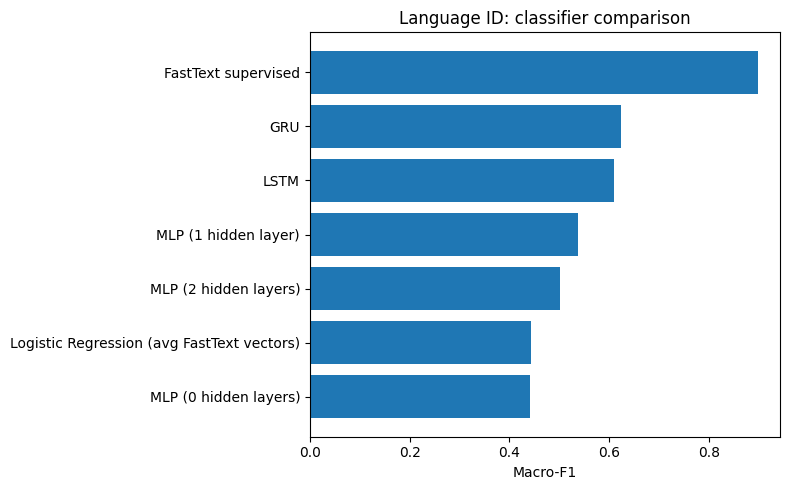

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(df["Model"], df["Macro-F1"])
plt.xlabel("Macro-F1")
plt.title("Language ID: classifier comparison")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Where to run this: Kaggle, not local VS Code

- **Internet access for 23 pretrained vector downloads.** Section 3 streams `wiki.{code}.vec.gz` for
  every language. Kaggle notebooks have an Internet toggle with solid bandwidth; a local VS Code setup
  depends on your own connection and, more importantly, on you remembering to actually enable network
  access if you're behind a restricted environment.
- **Free GPU.** The LSTM/GRU training (Sections 6) is meaningfully faster on a GPU. Kaggle gives you a
  free T4/P100 (Settings → Accelerator). Most laptops running VS Code won't have a usable GPU.
- **Disk/session limits are less of a worry.** We stream-filter the FastText files instead of saving
  full multi-GB vector files to disk, but Kaggle's larger scratch space is still a safety margin VS Code
  environments often lack.
- **Reproducible, shareable environment.** Kaggle notebooks pin package versions and are easy to share
  or re-run end-to-end for grading; a local VS Code setup depends on your own Python environment being
  in the same state next time.

**To run on Kaggle:**
1. New Notebook → Settings → Internet: **On**, Accelerator: **GPU T4 x2** (or P100).
2. Either (a) upload Assignment 1's `train.jsonl` / `val.jsonl` / `test.jsonl` as a Kaggle Dataset and set
   `DATA_DIR` to its path under `/kaggle/input/...`, or (b) leave `DATA_DIR = "data"` and let the fallback
   cell regenerate the dataset from IndicCorpV2 (slower, but needs no upload).
3. Run all cells top to bottom.

If you do want to develop locally in VS Code first (e.g. to debug small pieces without burning GPU quota),
that's fine for Sections 1–2 and 4–5 (CPU-only, few languages), but plan to move the full run — especially
Section 3's downloads and Sections 6–7's training — to Kaggle.
